# TrOCR

используем модель `microsoft/trocr-base-printed`, которая работает так: изображение на входе (картинка переводится в тензор) -> визуальный энкодер (энкодер извлекает визуальные признаки) -> текстовый декодер (декодер предсказывает первый символ, затем следующие до конца последовательности) -> текст на выходе

проверяем видюху

In [2]:
!nvidia-smi

Sat Apr 18 03:05:52 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

скачиваем нужные пакеты для работы с трансформером

In [3]:
!python -m pip install -q --upgrade pip
!python -m pip install -q transformers datasets evaluate accelerate sentencepiece jiwer pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 31.5 MB/s eta 0:00:00


монтируем гугл диск, в котором находится датасет

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


импорты

In [5]:
from __future__ import annotations
from pathlib import Path
import os
import re
import random
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import torch
from datasets import Dataset as HFDataset
from transformers import (
    TrOCRProcessor,
    VisionEncoderDecoderModel,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    default_data_collator,
    set_seed,
)
import evaluate

set_seed(42)
random.seed(42)
np.random.seed(42)

настраиваем пути

In [6]:
PROJECT_ROOT = Path('/content')
OCR_ROOT = Path('/content/drive/MyDrive/ocr_dataset')
PADDLE_LABEL_DIR = OCR_ROOT / 'paddleocr'

TRAIN_LABEL = PADDLE_LABEL_DIR / 'rec_gt_train.txt'
VALID_LABEL = PADDLE_LABEL_DIR / 'rec_gt_valid.txt'
TEST_LABEL = PADDLE_LABEL_DIR / 'rec_gt_test.txt'

OUTPUT_DIR = PROJECT_ROOT / 'trocr_ocr_experiments'
OUTPUT_DIR.mkdir(exist_ok=True)

MODEL_NAME = 'microsoft/trocr-base-printed'
TRAIN_WITH_NORMALIZED_TEXT = True

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# проверяем
print('DEVICE =', DEVICE)
print('MODEL_NAME =', MODEL_NAME)

DEVICE = cuda
MODEL_NAME = microsoft/trocr-base-printed


## Нормализация

так как в датасете самые разные номера машин из разных стран, алфавит тоже разный, поэтому нам нужно нормализировать значения. кириллицу превращаем в похожие на него латинские слова. это важно (метрика иначе будет ломаться), так как для  модели это разные символы, хотя они и визуально похожи.

In [7]:
SIMILAR_MAP = str.maketrans({
    'А': 'A', 'В': 'B', 'С': 'C', 'Е': 'E', 'Н': 'H',
    'К': 'K', 'М': 'M', 'О': 'O', 'Р': 'P', 'Т': 'T',
    'Х': 'X', 'У': 'Y',
    'а': 'A', 'в': 'B', 'с': 'C', 'е': 'E', 'н': 'H',
    'к': 'K', 'м': 'M', 'о': 'O', 'р': 'P', 'т': 'T',
    'х': 'X', 'у': 'Y',
})

def normalize_plate_text(text: str):
    return text.strip().upper().translate(SIMILAR_MAP)

def contains_cyrillic(text: str):
    return bool(re.search(r'[А-Яа-яЁё]', text))

def contains_latin(text: str):
    return bool(re.search(r'[A-Za-z]', text))

def mixed_script(text: str):
    return contains_cyrillic(text) and contains_latin(text)

# функция, которая берет строку и возвращает список словарей для будущего датасета
def read_rec_labels(path: Path):
    rows = []
    for line_no, line in enumerate(path.read_text(encoding='utf-8').splitlines(), start=1):
        if not line.strip():
            continue
        rel_path, text = line.split('\t', 1)
        text = text.strip()
        rows.append({
            'rel_path': rel_path,
            'image_path': str(OCR_ROOT / rel_path),
            'text_raw': text,
            'text_norm': normalize_plate_text(text),
            'is_mixed_script': mixed_script(text),
        })
    return rows

смотроим на наши выборки

In [8]:
splits = {
    'train': read_rec_labels(TRAIN_LABEL),
    'valid': read_rec_labels(VALID_LABEL),
    'test': read_rec_labels(TEST_LABEL),
}

# диагностируем наш датасет
for split_name, rows in splits.items():
    lengths = [len(row['text_raw']) for row in rows]
    missing = [row for row in rows if not Path(row['image_path']).exists()]
    print(
        split_name,
        'rows=', len(rows),
        'missing_images=', len(missing),
        'min_len=', min(lengths) if lengths else 0,
        'max_len=', max(lengths) if lengths else 0,
        'mixed_script=', sum(r['is_mixed_script'] for r in rows),
    )
# задаем в качестве целевой строки нормализованный текст
TEXT_FIELD = 'text_norm' if TRAIN_WITH_NORMALIZED_TEXT else 'text_raw'
print('TEXT_FIELD =', TEXT_FIELD)

train rows= 203 missing_images= 0 min_len= 2 max_len= 21 mixed_script= 0
valid rows= 63 missing_images= 0 min_len= 2 max_len= 11 mixed_script= 1
test rows= 29 missing_images= 0 min_len= 3 max_len= 10 mixed_script= 0
TEXT_FIELD = text_norm


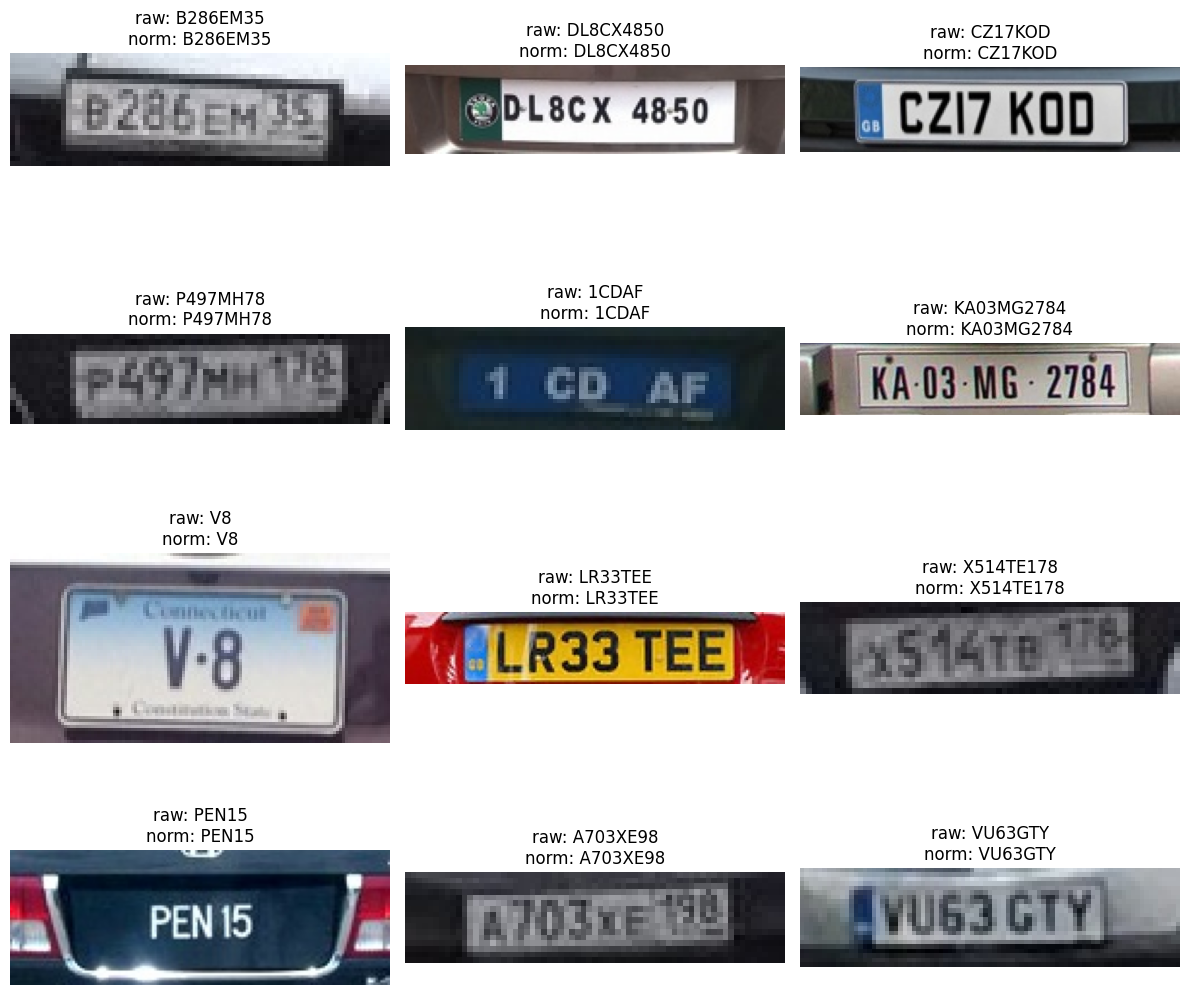

In [9]:
sample_rows = random.sample(splits['train'], k=min(12, len(splits['train'])))
cols = 3
rows_n = (len(sample_rows) + cols - 1) // cols

plt.figure(figsize=(12, max(3, rows_n * 2.8)))
for i, row in enumerate(sample_rows, start=1):
    img = Image.open(row['image_path']).convert('RGB')
    plt.subplot(rows_n, cols, i)
    plt.imshow(img)
    plt.title(f"raw: {row['text_raw']}\nnorm: {row['text_norm']}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## подготовка TrOCR

TrOCR использует `TrOCRProcessor` и `VisionEncoderDecoderModel`.

In [10]:
processor = TrOCRProcessor.from_pretrained(MODEL_NAME)
model = VisionEncoderDecoderModel.from_pretrained(MODEL_NAME)

# в конфиге модели указываем служебные токены и размер словаря
model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.config.pad_token_id = processor.tokenizer.pad_token_id
model.config.eos_token_id = processor.tokenizer.sep_token_id
model.config.vocab_size = model.config.decoder.vocab_size

model.generation_config.max_length = 32
# пока без бимсерча
model.generation_config.num_beams = 1
model.generation_config.length_penalty = 1.0
model.generation_config.no_repeat_ngram_size = 0

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-printed
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.weight | MISSING | 
encoder.pooler.dense.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

строим датасет хаггингфейса

In [11]:
train_df = pd.DataFrame(splits['train'])
valid_df = pd.DataFrame(splits['valid'])
test_df = pd.DataFrame(splits['test'])

train_ds = HFDataset.from_pandas(train_df)
valid_ds = HFDataset.from_pandas(valid_df)
test_ds = HFDataset.from_pandas(test_df)

In [12]:
train_ds, valid_ds, test_ds

(Dataset({
     features: ['rel_path', 'image_path', 'text_raw', 'text_norm', 'is_mixed_script'],
     num_rows: 203
 }),
 Dataset({
     features: ['rel_path', 'image_path', 'text_raw', 'text_norm', 'is_mixed_script'],
     num_rows: 63
 }),
 Dataset({
     features: ['rel_path', 'image_path', 'text_raw', 'text_norm', 'is_mixed_script'],
     num_rows: 29
 }))

превращаем один пример датасета в формат, понятный TrOCR

In [13]:
max_target_length = 32

def prepare_example(example):
  # 3 канала
    image = Image.open(example['image_path']).convert('RGB')
    # гоитовим изображение процессором
    pixel_values = processor(image, return_tensors='pt').pixel_values[0]

    text = example[TEXT_FIELD]
    # токенизация
    labels = processor.tokenizer(
        text,
        padding='max_length',
        max_length=max_target_length,
        truncation=True,
        return_tensors='pt'
    ).input_ids[0]

    labels = labels.clone()
    # не учитывать пад токен в лосс функции
    labels[labels == processor.tokenizer.pad_token_id] = -100

    return {
        'pixel_values': pixel_values,
        'labels': labels,
        'text_raw': example['text_raw'],
        'text_used': text,
        'image_path': example['image_path'],
    }

preprocessing датасета

In [14]:
train_ds_proc = train_ds.map(prepare_example, remove_columns=train_ds.column_names)
valid_ds_proc = valid_ds.map(prepare_example, remove_columns=valid_ds.column_names)
test_ds_proc = test_ds.map(prepare_example, remove_columns=test_ds.column_names)

train_ds_proc, valid_ds_proc

Map:   0%|          | 0/203 [00:00<?, ? examples/s]

Map:   0%|          | 0/63 [00:00<?, ? examples/s]

Map:   0%|          | 0/29 [00:00<?, ? examples/s]

(Dataset({
     features: ['image_path', 'text_raw', 'pixel_values', 'labels', 'text_used'],
     num_rows: 203
 }),
 Dataset({
     features: ['image_path', 'text_raw', 'pixel_values', 'labels', 'text_used'],
     num_rows: 63
 }))

построим функции метрик для оценки качества OCR модели. `cer` метрику загружаем, `levenshtein` (считает мин. кол-во операция над строкой для ее преобразования в другую строку), `char_accuracy` считает долю совпавших символов по позициям (она менее строгая, чем две предыдущие)

In [15]:
cer_metric = evaluate.load('cer')

def levenshtein(a: str, b: str) -> int:
    dp = [[0]*(len(b)+1) for _ in range(len(a)+1)]
    for i in range(len(a)+1):
        dp[i][0] = i
    for j in range(len(b)+1):
        dp[0][j] = j
    for i in range(1, len(a)+1):
        for j in range(1, len(b)+1):
            cost = 0 if a[i-1] == b[j-1] else 1
            dp[i][j] = min(
                dp[i-1][j] + 1,
                dp[i][j-1] + 1,
                dp[i-1][j-1] + cost
            )
    return dp[-1][-1]

def char_accuracy(true_text: str, pred_text: str) -> float:
    if len(true_text) == 0:
        return 1.0 if len(pred_text) == 0 else 0.0
    same = sum(1 for a, b in zip(true_text, pred_text) if a == b)
    return same / len(true_text)

функция подсчета метрик

In [ ]:
def compute_metrics(eval_pred):
    pred_ids = eval_pred.predictions
    label_ids = eval_pred.label_ids
# преобр. токены обратно в строки
    pred_str = processor.batch_decode(pred_ids, skip_special_tokens=True)
# возвращаем пад токен
    label_ids = np.where(label_ids == -100, processor.tokenizer.pad_token_id, label_ids)
    # преобр. токены обратно в строки
    label_str = processor.batch_decode(label_ids, skip_special_tokens=True)

    pred_str = [s.strip() for s in pred_str]
    label_str = [s.strip() for s in label_str]
# доля полного совпадения
    exact_match = np.mean([p == t for p, t in zip(pred_str, label_str)])

    pred_norm = [normalize_plate_text(s) for s in pred_str]
    label_norm = [normalize_plate_text(s) for s in label_str]
    norm_match = np.mean([p == t for p, t in zip(pred_norm, label_norm)])

    char_acc = np.mean([char_accuracy(t, p) for t, p in zip(label_str, pred_str)])
    cer = cer_metric.compute(predictions=pred_str, references=label_str)
    mean_lev = np.mean([levenshtein(t, p) for t, p in zip(label_str, pred_str)])

    return {
        'exact_match': float(exact_match),
        'norm_match': float(norm_match),
        'char_acc': float(char_acc),
        'cer': float(cer),
        'mean_levenshtein': float(mean_lev),
    }

## baseline

In [16]:
training_args = Seq2SeqTrainingArguments(
    output_dir=str(OUTPUT_DIR / 'trocr_base_printed_baseline'),
    predict_with_generate=True,
    eval_strategy='epoch',
    save_strategy='epoch',
    logging_strategy='steps',
    logging_steps=20,
    per_device_train_batch_size=8 if torch.cuda.is_available() else 4,
    per_device_eval_batch_size=8 if torch.cuda.is_available() else 4,
    fp16=torch.cuda.is_available(),
    num_train_epochs=5,
    learning_rate=3e-5,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model='norm_match',
    greater_is_better=True,
    report_to='none',
)

In [17]:
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    processing_class=processor,
    data_collator=default_data_collator,
    train_dataset=train_ds_proc,
    eval_dataset=valid_ds_proc,
    compute_metrics=compute_metrics,
)

обучение

In [18]:
train_result = trainer.train()
train_result

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': 0}.


Epoch,Training Loss,Validation Loss,Exact Match,Norm Match,Char Acc,Cer,Mean Levenshtein
1,2.340816,1.465995,0.380952,0.380952,0.703003,0.224176,1.619048
2,0.564899,1.584631,0.349206,0.349206,0.636088,0.217582,1.571429
3,0.625122,1.378070,0.492063,0.492063,0.776510,0.167033,1.206349
4,0.236603,1.113390,0.507937,0.507937,0.803526,0.153846,1.111111
5,0.094055,1.169987,0.507937,0.507937,0.798424,0.153846,1.111111


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['decoder.output_projection.weight'].


TrainOutput(global_step=130, training_loss=0.6232499727836022, metrics={'train_runtime': 858.3111, 'train_samples_per_second': 1.183, 'train_steps_per_second': 0.151, 'total_flos': 7.595094688609075e+17, 'train_loss': 0.6232499727836022, 'epoch': 5.0})

оценка после обучения

In [19]:
valid_metrics = trainer.evaluate(valid_ds_proc, metric_key_prefix='valid')
test_metrics = trainer.evaluate(test_ds_proc, metric_key_prefix='test')

print('VALID METRICS')
print(valid_metrics)

print('\nTEST METRICS')
print(test_metrics)

VALID METRICS
{'valid_loss': 1.1133899688720703, 'valid_exact_match': 0.5079365079365079, 'valid_norm_match': 0.5079365079365079, 'valid_char_acc': 0.8035256190018095, 'valid_cer': 0.15384615384615385, 'valid_mean_levenshtein': 1.1111111111111112, 'valid_runtime': 25.1955, 'valid_samples_per_second': 2.5, 'valid_steps_per_second': 0.318, 'epoch': 5.0}

TEST METRICS
{'test_loss': 0.6594463586807251, 'test_exact_match': 0.6896551724137931, 'test_norm_match': 0.6896551724137931, 'test_char_acc': 0.8822386425834702, 'test_cer': 0.0892018779342723, 'test_mean_levenshtein': 0.6551724137931034, 'test_runtime': 10.4666, 'test_samples_per_second': 2.771, 'test_steps_per_second': 0.382, 'epoch': 5.0}


In [20]:
def predict_dataset_rows(model, rows, max_items=12):
    model.eval()
    model.to(DEVICE)

    out = []
    for row in rows[:max_items]:
        image = Image.open(row['image_path']).convert('RGB')
        pixel_values = processor(image, return_tensors='pt').pixel_values.to(DEVICE)

        with torch.no_grad():
            generated_ids = model.generate(pixel_values, max_length=32, num_beams=1)
        pred_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()

        true_raw = row['text_raw']
        true_used = row[TEXT_FIELD]
        true_norm = normalize_plate_text(true_raw)
        pred_norm = normalize_plate_text(pred_text)

        out.append({
            'image_path': row['image_path'],
            'rel_path': row['rel_path'],
            'true_text_raw': true_raw,
            'true_text_used': true_used,
            'pred_text': pred_text,
            'exact_match_raw': pred_text == true_raw,
            'exact_match_used': pred_text == true_used,
            'norm_match': pred_norm == true_norm,
            'char_acc_used': char_accuracy(true_used, pred_text),
            'cer_used': levenshtein(true_used, pred_text) / max(1, len(true_used)),
            'lev_dist_used': levenshtein(true_used, pred_text),
        })
    return pd.DataFrame(out)

def show_predictions_with_images(pred_df, n=8):
    view_df = pred_df.head(n).copy()

    cols = 2
    rows_n = (len(view_df) + cols - 1) // cols
    plt.figure(figsize=(14, rows_n * 4))

    for i, (_, row) in enumerate(view_df.iterrows(), start=1):
        img = Image.open(row['image_path']).convert('RGB')

        plt.subplot(rows_n, cols, i)
        plt.imshow(img)
        plt.title(
            f"RAW: {row['true_text_raw']}\\n"
            f"USED: {row['true_text_used']}\\n"
            f"PRED: {row['pred_text']}\\n"
            f"norm_match={row['norm_match']} | char_acc={row['char_acc_used']:.2f}",
            fontsize=10
        )
        plt.axis('off')

    plt.tight_layout()
    plt.show()

,image_path,rel_path,true_text_raw,true_text_used,pred_text,exact_match_raw,exact_match_used,norm_match,char_acc_used,cer_used,lev_dist_used
0,/content/drive/MyDrive/ocr_dataset/crops/valid...,crops/valid/Cars114_png.rf.mCjkKpgHNNQh4k81COz...,AP29BP585,AP29BP585,RP29BP,False,False,False,0.555556,0.444444,4
1,/content/drive/MyDrive/ocr_dataset/crops/valid...,crops/valid/Cars122_png.rf.92Kwcwnm0hHZRrrVxqr...,MANISA,MANISA,MANISA,True,True,True,1.000000,0.000000,0
2,/content/drive/MyDrive/ocr_dataset/crops/valid...,crops/valid/Cars136_png.rf.3ji2gDSnQC7V1hwLSsn...,UA15474,UA15474,U15454,False,False,False,0.142857,0.285714,2
3,/content/drive/MyDrive/ocr_dataset/crops/valid...,crops/valid/Cars142_png.rf.P3TmbQNequLyYscExxa...,F1,F1,FI,False,False,False,0.500000,0.500000,1
4,/content/drive/MyDrive/ocr_dataset/crops/valid...,crops/valid/Cars164_png.rf.5czbMCxwmoEvZCly7Sd...,GT,GT,GTY,False,False,False,1.000000,0.500000,1
5,/content/drive/MyDrive/ocr_dataset/crops/valid...,crops/valid/Cars175_png.rf.TwwVEz8eLEhdM3iQChu...,DL1N4268,DL1N4268,DL1NAZ66,False,False,False,0.625000,0.375000,3
6,/content/drive/MyDrive/ocr_dataset/crops/valid...,crops/valid/Cars206_png.rf.YRYm7lnjCcglR1gcDZf...,HR26BU0380,HR26BU0380,HR26BU0380,True,True,True,1.000000,0.000000,0
7,/content/drive/MyDrive/ocr_dataset/crops/valid...,crops/valid/Cars238_png.rf.VCweL537NNjJSjP3xq5...,AD000008,AD000008,DAD00008,False,False,False,0.625000,0.250000,2
8,/content/drive/MyDrive/ocr_dataset/crops/valid...,crops/valid/Cars23_png.rf.7UEr1LLqlHlMdS7ut4i8...,9214,9214,9214,True,True,True,1.000000,0.000000,0
9,/content/drive/MyDrive/ocr_dataset/crops/valid...,crops/valid/Cars244_png.rf.8Z7ST9rYbbxCQ6cfpuS...,2180127,2180127,2180127,True,True,True,1.000000,0.000000,0


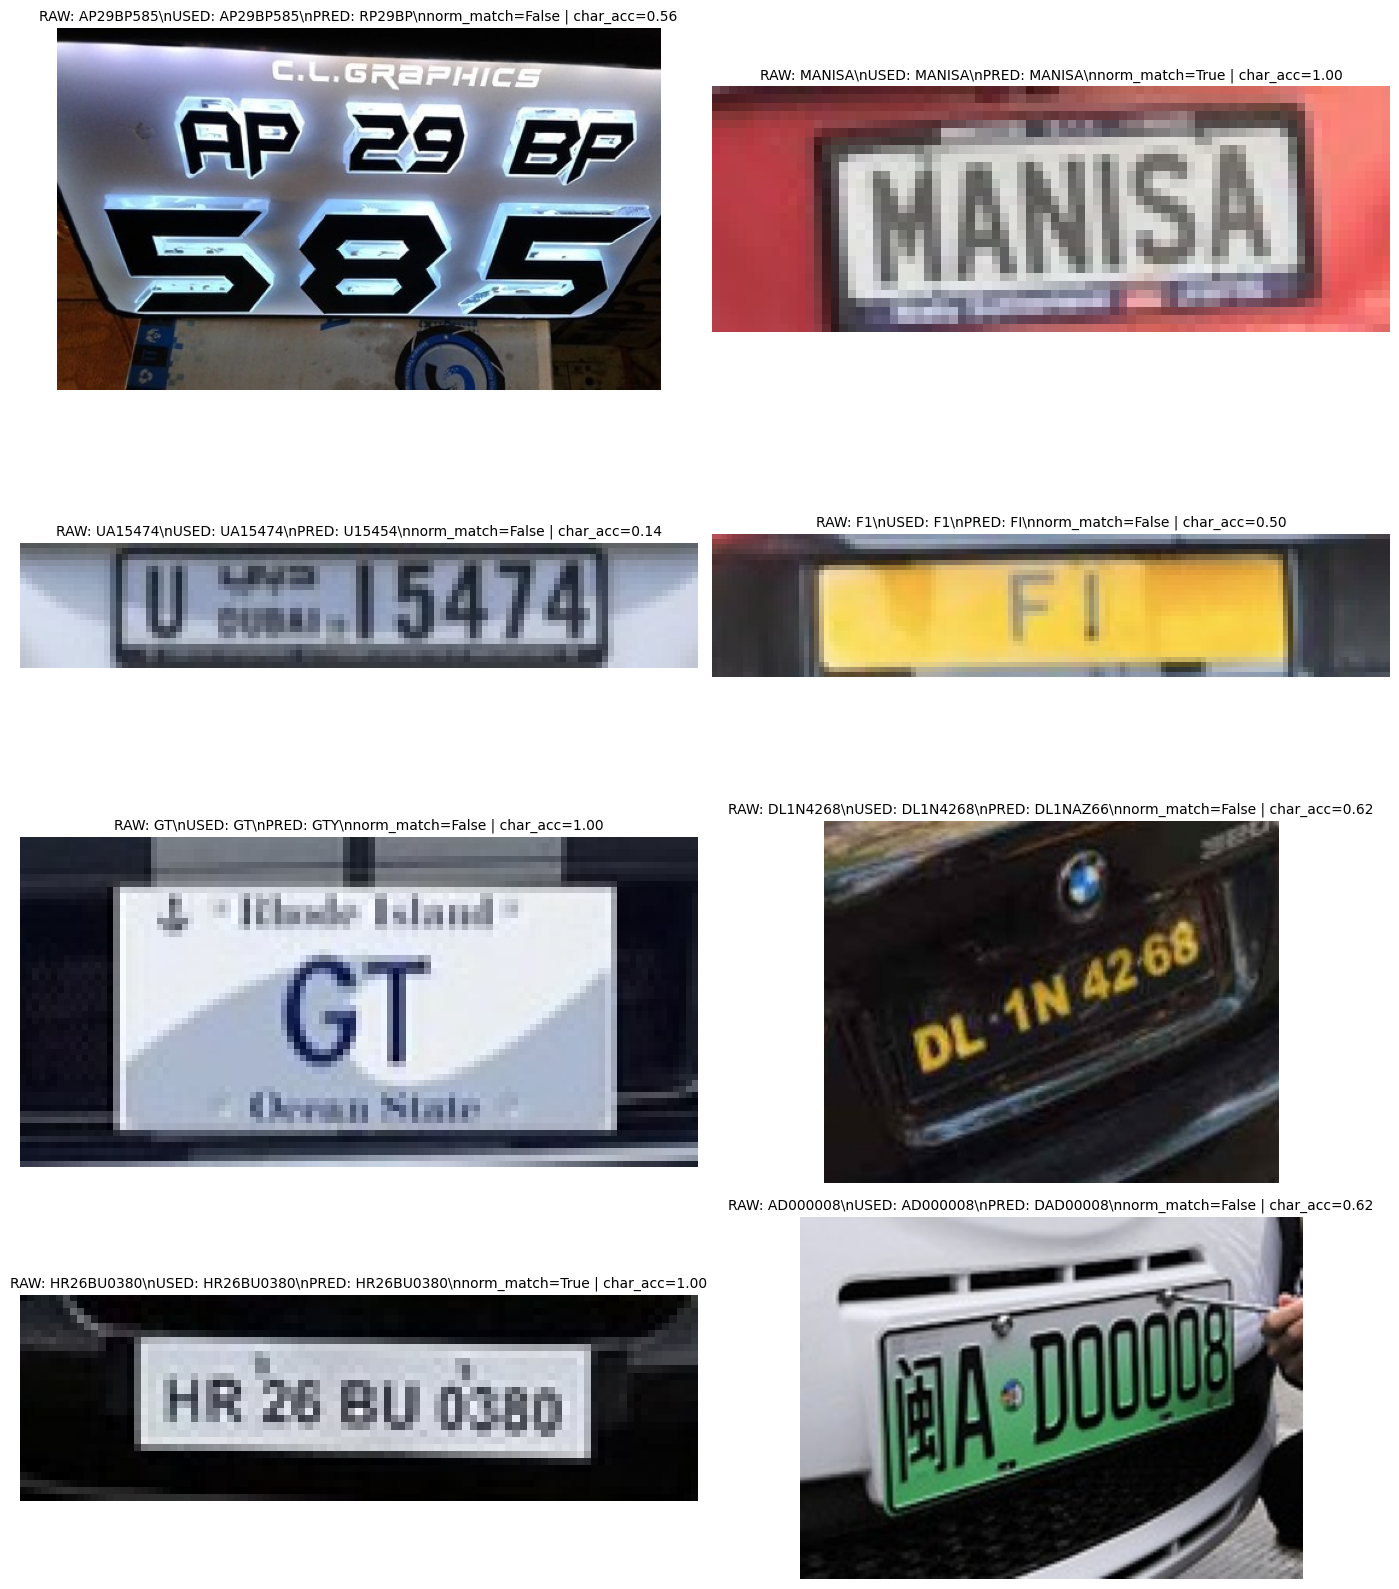

In [27]:
baseline_pred_df = predict_dataset_rows(trainer.model, splits['valid'], max_items=12)
display(baseline_pred_df)

show_predictions_with_images(baseline_pred_df, n=8)

In [22]:
def summarize_pred_df(df: pd.DataFrame):
    return pd.DataFrame([{
        'exact_match_raw': float(df['exact_match_raw'].mean()),
        'exact_match_used': float(df['exact_match_used'].mean()),
        'norm_match': float(df['norm_match'].mean()),
        'mean_char_acc_used': float(df['char_acc_used'].mean()),
        'mean_cer_used': float(df['cer_used'].mean()),
        'mean_lev_dist_used': float(df['lev_dist_used'].mean()),
    }])

In [23]:
print("BASELINE PRED SUMMARY")
display(summarize_pred_df(baseline_pred_df))

BASELINE PRED SUMMARY


,exact_match_raw,exact_match_used,norm_match,mean_char_acc_used,mean_cer_used,mean_lev_dist_used
0,0.416667,0.416667,0.416667,0.704034,0.24256,1.5


по этой таблице мы видим, что модель в 41% случаев идеально предсказала номер, средняя посимвольная точность составляет около 70.4%, `mean_cer_used` = 0.24256 примерно 24% символов распознаются неправильно. `mean_lev_dist_used` = 1.5 показывает, что модель в среднем допускает 1–2 ошибки на одну строку => baseline уже улавливает структуру текста, но пока недостаточно точен для устойчивого безошибочного распознавания. модель что-то да понимает, но часто ошибается, но это был тестовый прогон на 5 эпохах

сохраняем модель

In [24]:
best_model_dir = OUTPUT_DIR / 'trocr_base_printed_baseline' / 'best_model_export'
best_model_dir.mkdir(parents=True, exist_ok=True)

trainer.save_model(str(best_model_dir))
processor.save_pretrained(str(best_model_dir))

print(best_model_dir)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/content/trocr_ocr_experiments/trocr_base_printed_baseline/best_model_export


In [25]:
import shutil

archive_path = shutil.make_archive(
    str(best_model_dir),
    'zip',
    root_dir=str(best_model_dir)
)

print("Archive:", archive_path)

Archive: /content/trocr_ocr_experiments/trocr_base_printed_baseline/best_model_export.zip


In [26]:
from google.colab import files
files.download(archive_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>